<a href="https://colab.research.google.com/github/Gonza03s/intro-analisis-de-datos/blob/master/Copia_de_limpieza_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data cleaning con python

## Limpieza de datos duplicados

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [ ]:
df = pd.DataFrame({
    "id": [1, 2, 2, 3, 4, 5, 6],
    "nombre": ["Ana", "Juan", "Juan", "Luis", "María", "María", "Pedro"],
    "Localidad": ["Avellaneda", "Lanús", "Remedios de Escalada", "Lanús",
                  "Burzaco", "Burzaco", "Gerli"]
})

In [ ]:
df_con_duplicados = df.drop_duplicates()
print(df_con_duplicados)

   id nombre             Localidad
0   1    Ana            Avellaneda
1   2   Juan                 Lanús
2   2   Juan  Remedios de Escalada
3   3   Luis                 Lanús
4   4  María               Burzaco
5   5  María               Burzaco
6   6  Pedro                 Gerli


## Eliminar datos teniendo en cuenta solo una columna

In [ ]:
df_sin_duplicados = df.drop_duplicates(subset=["id"])
print(df_sin_duplicados)

   id nombre   Localidad
0   1    Ana  Avellaneda
1   2   Juan       Lanús
3   3   Luis       Lanús
4   4  Maria     Burzaco
5   5  Maria     Burzaco
6   6  Pedro       Gerli


## Eliminar datos teniendo en cuenta más de una columna

In [ ]:
df_sin_duplicados = df.drop_duplicates(subset=["nombre", "Localidad"])
print(df_sin_duplicados)

   id nombre             Localidad
0   1    Ana            Avellaneda
1   2   Juan                 Lanús
2   2   Juan  Remedios de Escalada
3   3   Luis                 Lanús
4   4  Maria               Burzaco
6   6  Pedro                 Gerli


## Corrección de valores perdidos

In [ ]:
data = {
    'A': [1, 2, np.nan, 4, 5],
    'B': [33, 2, 3, 66, 5],
    'C': [1, np.nan, 3, 4, np.nan]
}

df = pd.DataFrame(data)

In [ ]:
df

,A,B,C
0,1.0,33,1.0
1,2.0,2,NaN
2,NaN,3,3.0
3,4.0,66,4.0
4,5.0,5,NaN


### Eliminar todas las filas con valores perdidos

In [ ]:
df_completo = df.dropna()
print(df_completo)

     A   B    C
0  1.0  33  1.0
3  4.0  66  4.0


### Eliminar columnas con valores perdidos

In [ ]:
df_completo = df.dropna(axis=1)
print(df_completo)

    B
0  33
1   2
2   3
3  66
4   5


### Eliminar filas donde todos los valores son nulos

In [ ]:
df_completo = df.dropna(how='all')
print(df_completo)

     A   B    C
0  1.0  33  1.0
1  2.0   2  NaN
2  NaN   3  3.0
3  4.0  66  4.0
4  5.0   5  NaN


### Eliminar según ciertas columnas

In [ ]:
df_completo = df.dropna(subset=['A', 'B'])
print(df_completo)

     A   B    C
0  1.0  33  1.0
1  2.0   2  NaN
3  4.0  66  4.0
4  5.0   5  NaN


### Imputar valores nulos con medias o arbitrariamente

In [ ]:
df_ceros = df.fillna(0)  # Rellena con 0
print(df_ceros)


     A   B    C
0  1.0  33  1.0
1  2.0   2  0.0
2  0.0   3  3.0
3  4.0  66  4.0
4  5.0   5  0.0


In [ ]:
df_medias = df.fillna(df.mean())  # Rellena con la media de cada columna numérica
print(df_medias)


     A   B         C
0  1.0  33  1.000000
1  2.0   2  2.666667
2  3.0   3  3.000000
3  4.0  66  4.000000
4  5.0   5  2.666667


## Detección y tratamiento de valores atípicos o inconsistentes.

### Valores inconsistentes

In [ ]:
# Creamos un DataFrame con datos inconsistentes
df = pd.DataFrame({
    "edad": [25, "veinte", 30, 40],   # 'veinte' es incorrecto
    "salario": [3500.5, 2800.0, "4500", 5000.0],  # '4500' como string es incorrecto
    "ciudad": ["Madrid", "Lima", "Buenos Aires", "3 de Febrero"]
})


# Convertir edad y salario a su tipo correcto
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")   # Convierte a número, pone NaN si no se puede
df["salario"] = pd.to_numeric(df["salario"], errors="coerce")  # Lo mismo para salario

# Eliminar filas donde haya valores NaN por conversiones fallidas
df_limpio = df.dropna()

# Imprimir resultados
print(df_limpio)

   edad  salario        ciudad
0  25.0   3500.5        Madrid
2  30.0   4500.0  Buenos Aires
3  40.0   5000.0  3 de Febrero


También pueden existir inconsistencias que deberán ser detectadas por el analista y no serán de solución automática.

In [ ]:
# Creamos un DataFrame con datos inconsistentes
df = pd.DataFrame({
    "edad": [25, "veinte", 30, 40, 3500],   # 'veinte' es incorrecto
    "salario": [3500.5, 2800.0, "4500", 5000.0, 25],  # '4500' como string es incorrecto
    "ciudad": ["Madrid", "Lima", "Buenos Aires", "3 de Febrero", "Bogotá"]
})


# Convertir edad y salario a su tipo correcto
df["edad"] = pd.to_numeric(df["edad"], errors="coerce")   # Convierte a número, pone NaN si no se puede
df["salario"] = pd.to_numeric(df["salario"], errors="coerce")  # Lo mismo para salario

# Eliminar filas donde haya valores NaN por conversiones fallidas
df_limpio = df.dropna()

# Imprimir resultados
print(df_limpio)

     edad  salario        ciudad
0    25.0   3500.5        Madrid
2    30.0   4500.0  Buenos Aires
3    40.0   5000.0  3 de Febrero
4  3500.0     25.0        Bogotá


En este caso se deberá resolver manualmente usando pandas.

In [ ]:
df.loc[df.edad>120,
 ["edad", "salario"]] = df.loc[df.edad>120,
  ["salario", "edad"]].values
print(df)

   edad  salario        ciudad
0  25.0   3500.5        Madrid
1   NaN   2800.0          Lima
2  30.0   4500.0  Buenos Aires
3  40.0   5000.0  3 de Febrero
4  25.0   3500.0        Bogotá


### Valores atípicos

#### Detección visual

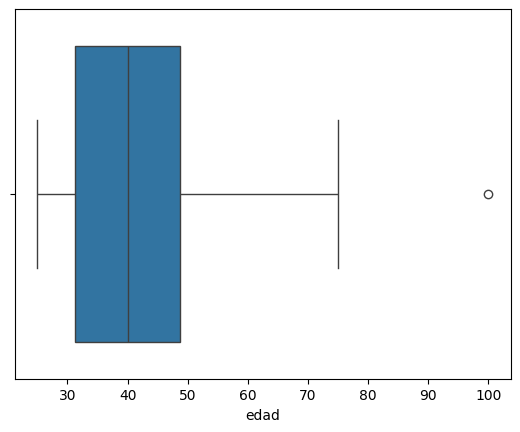

In [ ]:
df = pd.DataFrame({
    'edad': [25, 29, 30, 35, 40, 50, 100, 75, 40, 45],
    'salario': [3000, 4000, 3500, 4500, 5000, 5500, 10000, 15000, 6000, 7000]
})

# Crear un boxplot para detectar outliers en la columna 'edad'
sns.boxplot(x= df['edad'])
plt.show()

In [ ]:
print(df.edad.mean())
df.edad.std()

46.9


23.43999431171717

#### Detección estadística con el z-score

In [ ]:
# Calcular Z-Score para 'edad'
z_scores = stats.zscore(df['edad'])

print(z_scores)
# Detectar outliers (valores cuyo Z-Score es mayor que 2 o menor que -2)
outliers = df[abs(z_scores) > 2]

print(outliers)

[-0.98483927 -0.80495995 -0.75999012 -0.53514097 -0.31029183  0.13940647
  2.38789796  1.26365222 -0.31029183 -0.08544268]
   edad  salario
6   100    10000


#### Detección estadística mediante el rango intercuartílico

In [ ]:
# Calcular el rango intercuartílico (IQR)
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Limite inferior= {limite_inferior}")
print(f"Limite superior= {limite_superior}")

# Detectar outliers
outliers = df[(df['edad'] < limite_inferior) | (df['edad'] > limite_superior)]

print(outliers)

Limite inferior= 13.75
Limite superior= 43.75
Empty DataFrame
Columns: [edad, salario, ciudad]
Index: []


# Transformación de datos

## Por variable

In [ ]:
data = {'Valor': [1, 2, 4, 6, 7, 10],
        'Juez': [1, 1, 1, 2, 2, 2]}
df = pd.DataFrame(data)

# 1. Min-Max Scaling
df['MinMax'] = ((df['Valor'] - df['Valor'].min()) /
 (df['Valor'].max() - df['Valor'].min()))

# 2. Transformación Logarítmica (base e)
df['Log'] = np.log(df['Valor'] + 1)  # Se suma 1 para evitar log(0)

# 3. Z-score
df['Z-score'] = (df['Valor'] - df['Valor'].mean()) / df['Valor'].std()

# Mostrar resultado
print(df)

   Valor  Juez    MinMax       Log   Z-score
0      1     1  0.000000  0.693147 -1.195229
1      2     1  0.111111  1.098612 -0.896421
2      4     1  0.333333  1.609438 -0.298807
3      6     2  0.555556  1.945910  0.298807
4      7     2  0.666667  2.079442  0.597614
5     10     2  1.000000  2.397895  1.494036


## Por individuo

In [ ]:
def transformar(x: float, media: float,
                maximo: float, minimo: float)->float:
    if x < media:
        return (x - media) / (maximo - media)
    else:
        return (x - media) / (media - minimo)

def aplicar_por_juez(grupo: any)-> pd.DataFrame:
    media = grupo['Valor'].mean()
    maximo = grupo['Valor'].max()
    minimo = grupo['Valor'].min()
    grupo['Transformado'] = grupo['Valor'].apply(transformar,
                                                 args=(media, maximo, minimo))
    return grupo

In [ ]:
df = df.groupby('Juez', group_keys=False).apply(aplicar_por_juez)

print(df)

   Valor  Juez    MinMax       Log   Z-score  Transformado
0      1     1  0.000000  0.693147 -1.195229     -0.800000
1      2     1  0.111111  1.098612 -0.896421     -0.200000
2      4     1  0.333333  1.609438 -0.298807      1.250000
3      6     2  0.555556  1.945910  0.298807     -0.714286
4      7     2  0.666667  2.079442  0.597614     -0.285714
5     10     2  1.000000  2.397895  1.494036      1.400000


/tmp/ipykernel_2592/3996845021.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Juez', group_keys=False).apply(aplicar_por_juez)


Avellaneda
300.000 habitantes
300 encuestas
1000 ponderación

¿qué candidato?
100 no responden-> ponderador va a ser 0
200 respondentes -> (300 / 200) *  ponderador

Lanús
300 encuestas
450.000 habitantes
1500 ponderación